# Sprint 13. Proyecto del módulo 2

**Descripción del ejercicio**

Prepara un prototipo de un modelo de machine learning para Zyfra. La empresa desarrolla soluciones de eficiencia para la industria pesada.

El modelo debe predecir la cantidad de oro extraído del mineral de oro. Dispones de los datos de extracción y purificación.

El modelo ayudará a optimizar la producción y a eliminar los parámetros no rentables.

Tendrás que:

1. Preparar los datos.
2. Realizar el análisis de datos.
3. Desarrollar un modelo y entrenarlo.

In [34]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

# 1. Prepara los datos

## 1.1 Abre los archivos y examina los datos

In [2]:
# Leer los archivos
gold_recovery_full_df = pd.read_csv("datasets/gold_recovery_full.csv")
gold_recovery_test_df = pd.read_csv("datasets/gold_recovery_test.csv")
gold_recovery_train_df = pd.read_csv("datasets/gold_recovery_train.csv")

In [3]:
print(gold_recovery_full_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


In [4]:
print(gold_recovery_test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

In [5]:
print(gold_recovery_train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [6]:
print(gold_recovery_full_df.head())

                  date  final.output.concentrate_ag  \
0  2016-01-15 00:00:00                     6.055403   
1  2016-01-15 01:00:00                     6.029369   
2  2016-01-15 02:00:00                     6.055926   
3  2016-01-15 03:00:00                     6.047977   
4  2016-01-15 04:00:00                     6.148599   

   final.output.concentrate_pb  final.output.concentrate_sol  \
0                     9.889648                      5.507324   
1                     9.968944                      5.257781   
2                    10.213995                      5.383759   
3                     9.977019                      4.858634   
4                    10.142511                      4.939416   

   final.output.concentrate_au  final.output.recovery  final.output.tail_ag  \
0                    42.192020              70.541216             10.411962   
1                    42.701629              69.266198             10.462676   
2                    42.657501              68.

In [7]:
print(gold_recovery_train_df.head())

                  date  final.output.concentrate_ag  \
0  2016-01-15 00:00:00                     6.055403   
1  2016-01-15 01:00:00                     6.029369   
2  2016-01-15 02:00:00                     6.055926   
3  2016-01-15 03:00:00                     6.047977   
4  2016-01-15 04:00:00                     6.148599   

   final.output.concentrate_pb  final.output.concentrate_sol  \
0                     9.889648                      5.507324   
1                     9.968944                      5.257781   
2                    10.213995                      5.383759   
3                     9.977019                      4.858634   
4                    10.142511                      4.939416   

   final.output.concentrate_au  final.output.recovery  final.output.tail_ag  \
0                    42.192020              70.541216             10.411962   
1                    42.701629              69.266198             10.462676   
2                    42.657501              68.

In [8]:
print(gold_recovery_test_df.head())

                  date  primary_cleaner.input.sulfate  \
0  2016-09-01 00:59:59                     210.800909   
1  2016-09-01 01:59:59                     215.392455   
2  2016-09-01 02:59:59                     215.259946   
3  2016-09-01 03:59:59                     215.336236   
4  2016-09-01 04:59:59                     199.099327   

   primary_cleaner.input.depressant  primary_cleaner.input.feed_size  \
0                         14.993118                         8.080000   
1                         14.987471                         8.080000   
2                         12.884934                         7.786667   
3                         12.006805                         7.640000   
4                         10.682530                         7.530000   

   primary_cleaner.input.xanthate  primary_cleaner.state.floatbank8_a_air  \
0                        1.005021                             1398.981301   
1                        0.990469                             1398.777

## 1.2 Comprueba que el cálculo de la recuperación sea correcto.

In [9]:
print(gold_recovery_train_df['rougher.output.recovery'].head())

0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
Name: rougher.output.recovery, dtype: float64


In [10]:
print(gold_recovery_train_df['rougher.output.recovery'].isnull().sum())

2573


In [11]:
# Calcular la recuperación manualmente
C = gold_recovery_train_df['rougher.output.concentrate_au']
F = gold_recovery_train_df['rougher.input.feed_au']
T = gold_recovery_train_df['rougher.output.tail_au']

recovery_calculation = (C * (F - T)) / (F * (C - T)) * 100

print(recovery_calculation.head())

0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
dtype: float64


In [12]:
# Quitar filas con valores nulos
rougher_output_recovery = gold_recovery_train_df['rougher.output.recovery'].dropna()

rougher_output_recovery_calculation = recovery_calculation.loc[
    recovery_calculation.index.isin(rougher_output_recovery.index)
]

print(f"Tamaño (columna recovery): {rougher_output_recovery.shape}")
print(f"Tamaño (calculo manual): {rougher_output_recovery_calculation.shape}")

Tamaño (columna recovery): (14287,)
Tamaño (calculo manual): (14287,)


In [13]:
# Comparar con los valores reales
eam = mean_absolute_error(rougher_output_recovery, rougher_output_recovery_calculation)
print(eam)
print(f"EAM: {eam:.15f}")

9.210911277458828e-15
EAM: 0.000000000000009


Se obtuvo 9.210911277458828e-15 en el calculo del error absoluto medio, prácticamente 0, por lo que confirma que los datos de la columna "rougher_output_recovery" estan calculados correctamente.

## 1.3. Analiza las características no disponibles en el conjunto de prueba.

In [38]:
filter = ~gold_recovery_train_df.columns.isin(gold_recovery_test_df.columns)
print(filter)

[False  True  True  True  True  True  True  True  True  True False False
 False False  True  True  True  True  True  True  True  True False False
 False False False False False False  True  True  True  True False False
 False False False False False False False False  True  True  True  True
  True  True  True  True  True False False False False False False False
 False False False False False  True  True  True  True False False False
 False False False False False False False False False False False False
 False False False]


In [41]:
print(gold_recovery_train_df.loc[:,filter].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16860 non-null  float64
 1   final.output.concentrate_pb                         16860 non-null  float64
 2   final.output.concentrate_sol                        16860 non-null  float64
 3   final.output.concentrate_au                         16860 non-null  float64
 4   final.output.recovery                               16860 non-null  float64
 5   final.output.tail_ag                                16860 non-null  float64
 6   final.output.tail_pb                                16860 non-null  float64
 7   final.output.tail_sol                               16860 non-null  float64
 8   final.output.tail_au                                16860 non-null  float64


In [ ]:

# features_not_available_df = gold_recovery_train_df.loc[
#     :,
#     ~gold_recovery_train_df.columns.isin(gold_recovery_test_df.columns)
# ]

# print(features_not_available_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tail_au                                16794 non-null  float64


Las columnas que no se encuentran en el conujunto de prueba pero si en el conjunto de entrenamiento son aquellas columnas con el tipo de parametro output (salidas) de tipo float.

In [ ]:
# Dividiendo características y objetivos
target_train = gold_recovery_train_df[["rougher.output.recovery", "final.output.recovery"]]
features_train = gold_recovery_train_df.loc[:, gold_recovery_train_df.columns.isin(gold_recovery_test_df.columns)]

## 1.4. Realiza el preprocesamiento de datos.

Resolver el problema de los nulos

In [15]:
print(gold_recovery_train_df.isna().sum())

date                                            0
final.output.concentrate_ag                    72
final.output.concentrate_pb                    72
final.output.concentrate_sol                  370
final.output.concentrate_au                    71
                                             ... 
secondary_cleaner.state.floatbank5_a_level     85
secondary_cleaner.state.floatbank5_b_air       85
secondary_cleaner.state.floatbank5_b_level     84
secondary_cleaner.state.floatbank6_a_air      103
secondary_cleaner.state.floatbank6_a_level     85
Length: 87, dtype: int64


In [16]:
print(gold_recovery_test_df.isna().sum())

date                                            0
primary_cleaner.input.sulfate                 302
primary_cleaner.input.depressant              284
primary_cleaner.input.feed_size                 0
primary_cleaner.input.xanthate                166
primary_cleaner.state.floatbank8_a_air         16
primary_cleaner.state.floatbank8_a_level       16
primary_cleaner.state.floatbank8_b_air         16
primary_cleaner.state.floatbank8_b_level       16
primary_cleaner.state.floatbank8_c_air         16
primary_cleaner.state.floatbank8_c_level       16
primary_cleaner.state.floatbank8_d_air         16
primary_cleaner.state.floatbank8_d_level       16
rougher.input.feed_ag                          16
rougher.input.feed_pb                          16
rougher.input.feed_rate                        40
rougher.input.feed_size                        22
rougher.input.feed_sol                         67
rougher.input.feed_au                          16
rougher.input.floatbank10_sulfate             257


In [17]:
# Diferencia al eliminar los nulos
print(gold_recovery_train_df.shape)
print(gold_recovery_train_df.dropna().shape)

(16860, 87)
(11017, 87)


In [18]:
gold_recovery_train_df = gold_recovery_train_df.bfill()
gold_recovery_test_df = gold_recovery_test_df.bfill()

print(gold_recovery_train_df.isna().sum())

date                                          0
final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
                                             ..
secondary_cleaner.state.floatbank5_a_level    0
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
Length: 87, dtype: int64


Eliminar columnas en el conjunto de entrenamiento que no se encuntran en el conjunto de prueba

In [19]:
features_not_available = features_not_available_df.columns.to_list()

print(features_not_available)

['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.concentrate_au', 'rougher.output.recovery', 'rougher.output.tail_ag', 'rougher.output.tail_pb', 'rougher.output.tail_sol', 'rougher.output.tai

In [20]:
# Quital las columnas objetivo la lista a eliminar
features_not_available.remove('rougher.output.recovery')
features_not_available.remove('final.output.recovery')

print(features_not_available)

['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.concentrate_au', 'rougher.output.tail_ag', 'rougher.output.tail_pb', 'rougher.output.tail_sol', 'rougher.output.tail_au', 'secondary_cleaner.output.tail_ag', 'secondar

In [21]:
gold_recovery_train_updated_df = gold_recovery_train_df.drop(features_not_available, axis=1)

gold_recovery_train_updated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        16860 non-null  object 
 1   final.output.recovery                       16860 non-null  float64
 2   primary_cleaner.input.sulfate               16860 non-null  float64
 3   primary_cleaner.input.depressant            16860 non-null  float64
 4   primary_cleaner.input.feed_size             16860 non-null  float64
 5   primary_cleaner.input.xanthate              16860 non-null  float64
 6   primary_cleaner.state.floatbank8_a_air      16860 non-null  float64
 7   primary_cleaner.state.floatbank8_a_level    16860 non-null  float64
 8   primary_cleaner.state.floatbank8_b_air      16860 non-null  float64
 9   primary_cleaner.state.floatbank8_b_level    16860 non-null  float64
 10  primary_cl

Se eliminaron las columnas del conjunto de entrenamiento que no se encuentran en el conjunto de prueba, manteniendo los 2 columnas objetivo.
También se resolvio el problema de los nulos asignandole el valor del siguiente registro.

# 2. Analiza los datos

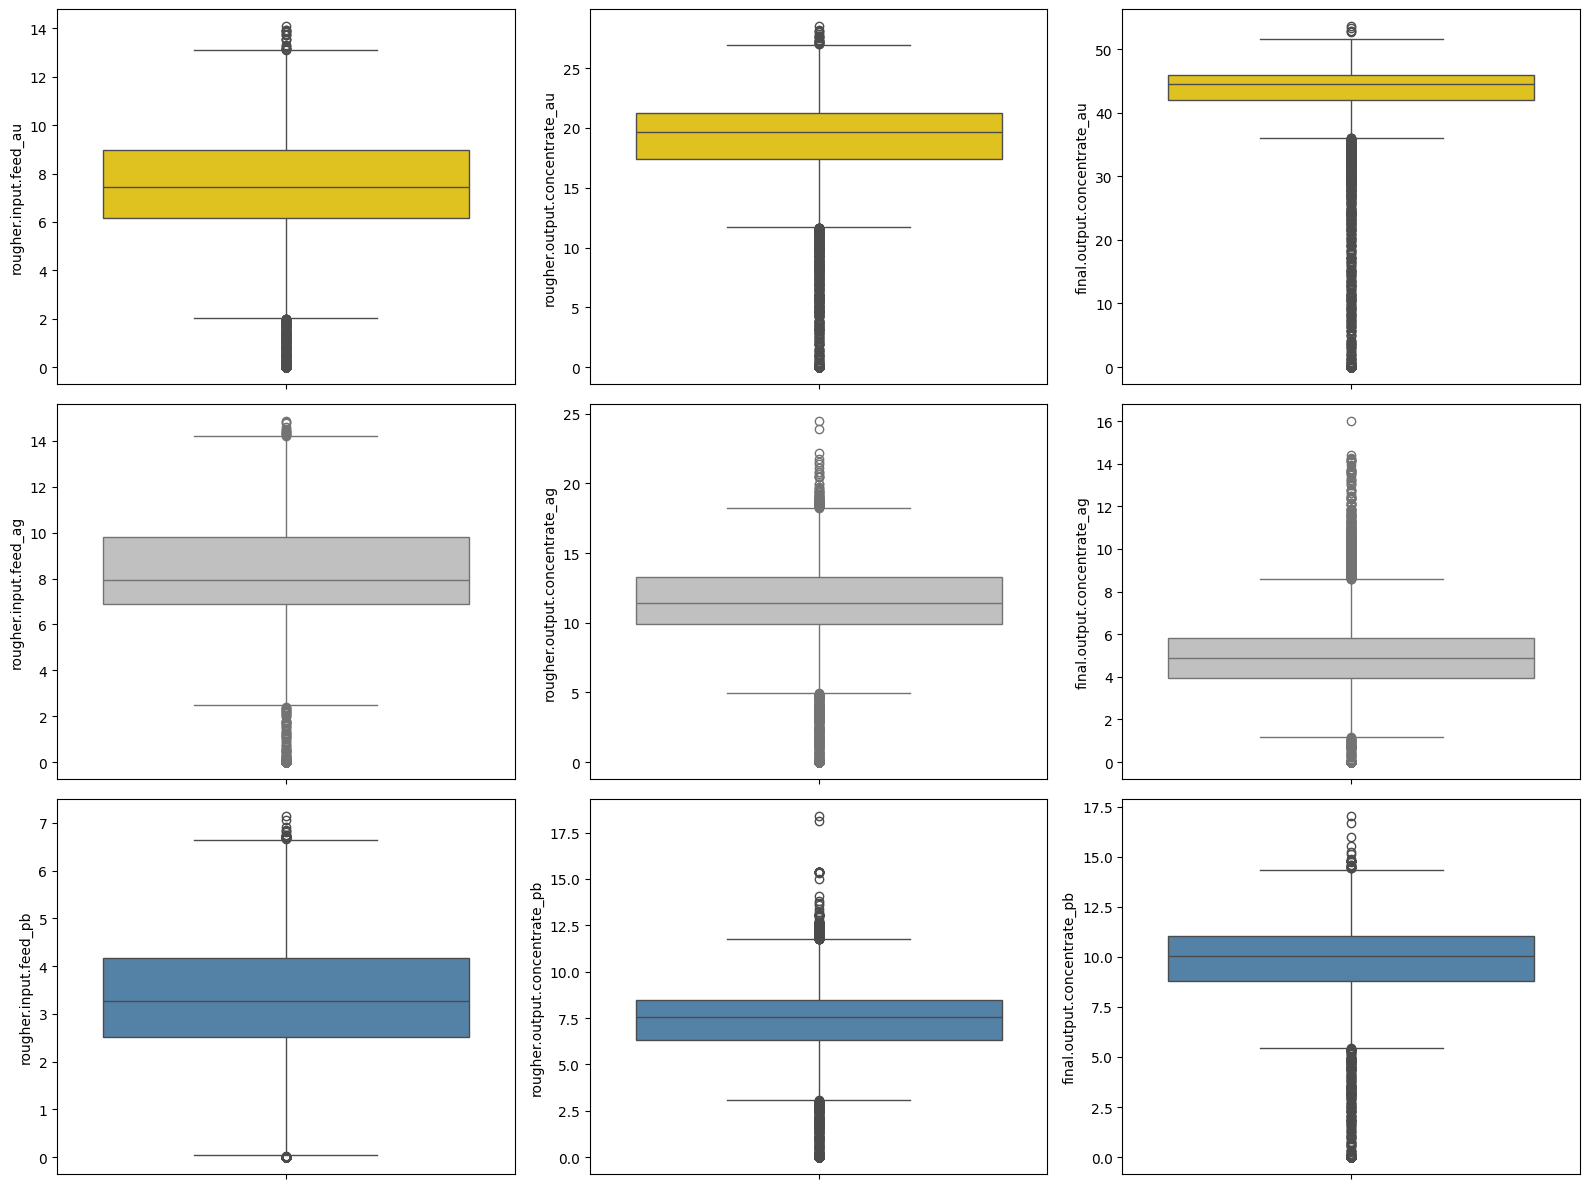

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

# Subplot - Fases del oro
sns.boxplot(y=gold_recovery_train_df["rougher.input.feed_au"], ax=axes[0,0], color="gold")
sns.boxplot(y=gold_recovery_train_df["rougher.output.concentrate_au"], ax=axes[0,1], color="gold")
sns.boxplot(y=gold_recovery_train_df["final.output.concentrate_au"], ax=axes[0,2], color="gold")

# Subplot - Fases del plata
sns.boxplot(y=gold_recovery_train_df["rougher.input.feed_ag"], ax=axes[1,0], color="silver")
sns.boxplot(y=gold_recovery_train_df["rougher.output.concentrate_ag"], ax=axes[1,1], color="silver")
sns.boxplot(y=gold_recovery_train_df["final.output.concentrate_ag"], ax=axes[1,2], color="silver")

# Subplot - Fases del plomo
sns.boxplot(y=gold_recovery_train_df["rougher.input.feed_pb"], ax=axes[2,0], color="steelblue")
sns.boxplot(y=gold_recovery_train_df["rougher.output.concentrate_pb"], ax=axes[2,1], color="steelblue")
sns.boxplot(y=gold_recovery_train_df["final.output.concentrate_pb"], ax=axes[2,2], color="steelblue")


plt.tight_layout()
plt.show()

- Se observa que el porcentaje de purificación del oro ha subido, es lo que se prentende en este proceso.
- Para la plata ha ocurrido algo diferente, primero ha subido y luego ha descendido más que al inicio.
- El porcentaje del plomo ha subido ligeramente.

## 2.2 

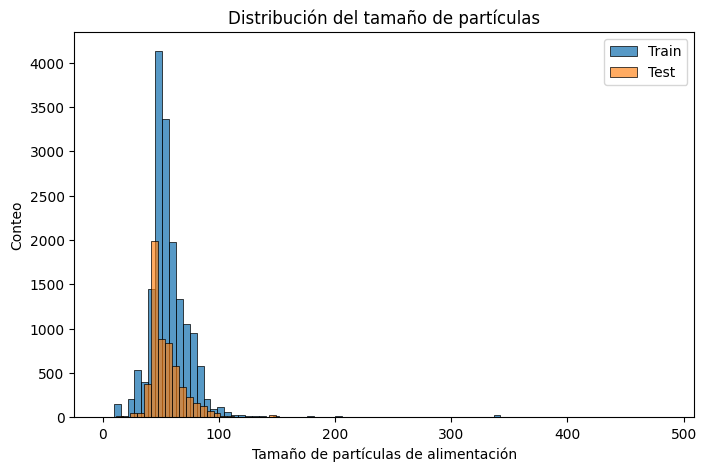

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(data=gold_recovery_train_df["rougher.input.feed_size"], bins=80, label="Train")
sns.histplot(data=gold_recovery_test_df["rougher.input.feed_size"], bins=80, label="Test", alpha=0.65)

plt.legend()
plt.title("Distribución del tamaño de partículas")
plt.xlabel("Tamaño de partículas de alimentación")
plt.ylabel("Conteo")
plt.show()

Ya que los picos de ambas distribuciones ocurren aproximadamente en el mismo valor del tamaño de particulas, indicando que ambos conjuntos proviene de la misma distribución subyacente. 

# 2.3

In [24]:
# Sumar las concentraciones para la etapa de materia prima
total_concentration_input_feed = (gold_recovery_train_df["rougher.input.feed_au"] + 
                                  gold_recovery_train_df["rougher.input.feed_ag"] +
                                  gold_recovery_train_df["rougher.input.feed_pb"])

# Sumar las concentraciones para la etapa de concentrado rougher
total_concentration_output_concentrate = (gold_recovery_train_df["rougher.output.concentrate_au"] + 
                                          gold_recovery_train_df["rougher.output.concentrate_ag"] +
                                          gold_recovery_train_df["rougher.output.concentrate_pb"])

# Sumar las concentraciones para la etapa concentrado final
total_concentration_final_output = (gold_recovery_train_df["final.output.concentrate_au"] + 
                                    gold_recovery_train_df["final.output.concentrate_ag"] +
                                    gold_recovery_train_df["final.output.concentrate_pb"])

print(total_concentration_input_feed.head())

0    14.871440
1    14.905729
2    14.638299
3    14.199305
4    13.511497
dtype: float64


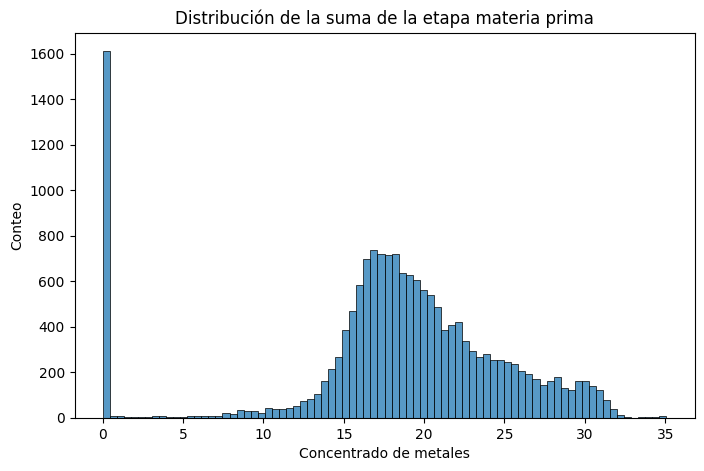

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(data=total_concentration_input_feed, bins=80)

plt.title("Distribución de la suma de la etapa materia prima")
plt.xlabel("Concentrado de metales")
plt.ylabel("Conteo")
plt.show()

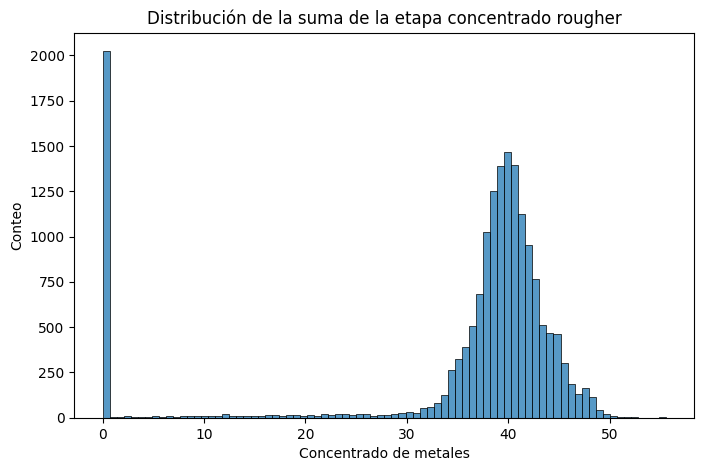

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(data=total_concentration_output_concentrate, bins=80)

plt.title("Distribución de la suma de la etapa concentrado rougher")
plt.xlabel("Concentrado de metales")
plt.ylabel("Conteo")
plt.show()

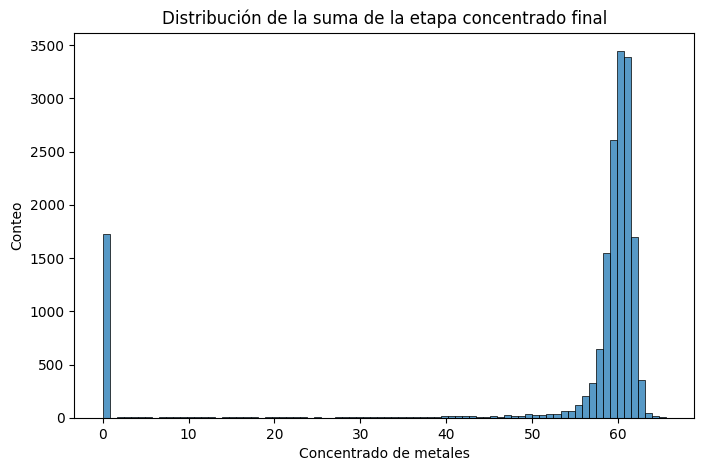

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(data=total_concentration_final_output, bins=80)

plt.title("Distribución de la suma de la etapa concentrado final")
plt.xlabel("Concentrado de metales")
plt.ylabel("Conteo")
plt.show()

Hay una gran cantidad de ceros, no tiene sentido por que eso sugeriria que no hay material.

In [28]:
# Eliminar los valores 0 para el conjunto de entrenamiento
filter_gold_rec_train_df = gold_recovery_train_updated_df[
    (total_concentration_input_feed > 0) & 
    (total_concentration_output_concentrate > 0) & 
    (total_concentration_final_output > 0)
]

print(f"Tamaño antes: {gold_recovery_train_df.shape}")
print(f"Tamaño después: {filter_gold_rec_train_df.shape}")

Tamaño antes: (16860, 87)
Tamaño después: (15124, 55)


In [29]:
# Eliminar los valores 0 para el conjunto de prueba

# obtener las filas completas de test de full
gold_recovery_test_full_df = gold_recovery_full_df.loc[
    gold_recovery_test_df.index
]

# realizar los calculos
# Sumar las concentraciones para la etapa de materia prima
total_conc_input_feed_test = (gold_recovery_test_full_df["rougher.input.feed_au"] + 
                                  gold_recovery_test_full_df["rougher.input.feed_ag"] +
                                  gold_recovery_test_full_df["rougher.input.feed_pb"])

# Sumar las concentraciones para la etapa de concentrado rougher
total_conc_output_concentrate_test = (gold_recovery_test_full_df["rougher.output.concentrate_au"] + 
                                          gold_recovery_test_full_df["rougher.output.concentrate_ag"] +
                                          gold_recovery_test_full_df["rougher.output.concentrate_pb"])

# Sumar las concentraciones para la etapa concentrado final
total_conc_final_output_test = (gold_recovery_test_full_df["final.output.concentrate_au"] + 
                                    gold_recovery_test_full_df["final.output.concentrate_ag"] +
                                    gold_recovery_test_full_df["final.output.concentrate_pb"])

# filtrar el dataset de prueba
filter_gold_rec_test_df = gold_recovery_test_df[
    (total_conc_input_feed_test > 0) &
    (total_conc_output_concentrate_test > 0) &
    (total_conc_final_output_test)
]

print(f"Tamaño antes: {gold_recovery_test_df.shape}")
print(f"Tamaño después: {filter_gold_rec_test_df.shape}")

Tamaño antes: (5856, 53)
Tamaño después: (5133, 53)


Se eliminó las filas en las que en cada etapa la concentración total era igua a 0 para ambos conjuntos de datos (train y test).
- Para el conjunto de entrenamiento se eliminaron aproximandamente: 1700 registros.
- Para el conjunto de prueba se eliminaron aproximandamente: 700 registros.

# 3 Contruye el modelo

In [ ]:
features_train, target_train = train_test_split

## 3.1 Función sMAPE

In [30]:
# función sMAPE
def smape(target_real, target_pred):
    n = np.abs(target_real - target_pred)
    d = (np.abs(target_real) + np.abs(target_pred)) / 2
    t = (n / d).sum()
    return (t / len(target_real)) * 100


# 3.2 Entrena diferentes modelos

### Árboles de decisión

In [31]:
# tree_model = DecisionTreeClassifier(random_state=12345)
# tree_model_score = cross_val_score(tree_model, gold, )

### Regresión lineal

In [33]:
# line_model = 

### Bosque aleatorio